# Healthcare Analytics for Doctor Visits
### DIY Project — Radheshyam Suthar
**Goal:** Analyze patterns in doctor visits and examine how demographic, health, illness, activity-reduction, and healthcare-access variables are associated with recorded visits.

> **Important:** The analysis describes associations in the supplied dataset. It does not establish causal relationships or medical conclusions.


## 1. Problem Statement

Doctor-visit records contain information about healthcare utilization, demographic characteristics, health conditions, illness, activity reduction, income, insurance/access indicators, and chronic conditions. The project analyzes these variables to identify measurable patterns in the number of recorded doctor visits and to summarize statistically supported relationships in the dataset.

## 2. Analytical Questions

1. How are doctor visits distributed in the dataset?
2. How do recorded visits vary by gender and age?
3. Is income associated with doctor visits?
4. How are illness, health status, and activity reduction related to visits?
5. Do chronic-condition and healthcare-access indicators differ in recorded visit levels?
6. Which variables show statistically detectable associations with doctor visits?
7. Can a count-based regression model summarize the relationship between visits and the available predictors?


In [3]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 3. Load Dataset

The dataset is loaded directly from the project's public GitHub repository so the notebook can be executed in a fresh Google Colab runtime without manually uploading the CSV.

**GitHub repository:** https://github.com/Radhe-jangir/healthcare-analytics-doctor-visits

The loader includes a small filename fallback so the notebook can still locate the CSV if the original VOIS filename was retained in the repository.


In [4]:
# ===== DATASET LOADER (GitHub) =====
import io
import urllib.request

GITHUB_REPO = "https://github.com/Radhe-jangir/healthcare-analytics-doctor-visits"
GITHUB_CSV_URL = "https://raw.githubusercontent.com/Radhe-jangir/healthcare-analytics-doctor-visits/main/healthcare_doctor_visits.csv"

# The primary URL above is the filename recommended for the GitHub repository.
# The alternate filenames below make the notebook tolerant if the uploaded CSV
# retained its original VOIS filename.
CANDIDATE_URLS = [
    GITHUB_CSV_URL,
    "https://raw.githubusercontent.com/Radhe-jangir/healthcare-analytics-doctor-visits/main/1776250375-P2-Healthcare%20Analytics%20for%20Doctor%20Visits%20%281%29.csv",
    "https://raw.githubusercontent.com/Radhe-jangir/healthcare-analytics-doctor-visits/main/1776250375-P2-Healthcare%20Analytics%20for%20Doctor%20Visits.csv",
]

df = None
source_used = None
last_error = None

for url in CANDIDATE_URLS:
    try:
        with urllib.request.urlopen(url, timeout=20) as response:
            df = pd.read_csv(response)
        source_used = url
        break
    except Exception as e:
        last_error = e

if df is None:
    raise FileNotFoundError(
        "GitHub dataset could not be loaded. Check that the CSV is uploaded to the repository and that its filename matches one of the supported names."
    ) from last_error

print("Dataset loaded successfully from GitHub.")
print("Source:", source_used)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

assert df.shape[0] == 5190, f"Unexpected row count: {df.shape[0]}"
print("Dataset verification: PASSED")


Dataset loaded successfully from GitHub.
Source: https://raw.githubusercontent.com/Radhe-jangir/healthcare-analytics-doctor-visits/main/healthcare_doctor_visits.csv
Rows: 5190
Columns: 13
Dataset verification: PASSED


In [5]:
# Dataset verification
EXPECTED_ROWS = 5190
EXPECTED_COLUMNS = 13

assert df.shape == (EXPECTED_ROWS, EXPECTED_COLUMNS), (
    f"Unexpected dataset shape: {df.shape}"
)

required_columns = {
    "visits", "gender", "age", "income", "illness", "reduced",
    "health", "private", "freepoor", "freerepat", "nchronic", "lchronic"
}
missing_required = required_columns - set(df.columns)
assert not missing_required, f"Missing required columns: {missing_required}"

print("Dataset verification: PASSED")


Dataset verification: PASSED


## 4. Initial Data Understanding

In [6]:
display(df.head())
display(df.tail())
print("Shape:", df.shape)
df.info()


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


Shape: (5190, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [7]:
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,5190.0,NaN,NaN,NaN,2595.5,1498.368279,1.0,1298.25,2595.5,3892.75,5190.0
visits,5190.0,NaN,NaN,NaN,0.301734,0.798134,0.0,0.0,0.0,0.0,9.0
gender,5190,2,female,2702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5190.0,NaN,NaN,NaN,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,NaN,NaN,NaN,0.58316,0.368907,0.0,0.25,0.55,0.9,1.5
illness,5190.0,NaN,NaN,NaN,1.431985,1.384152,0.0,0.0,1.0,2.0,5.0
reduced,5190.0,NaN,NaN,NaN,0.86185,2.887628,0.0,0.0,0.0,0.0,14.0
health,5190.0,NaN,NaN,NaN,1.217534,2.124266,0.0,0.0,0.0,2.0,12.0
private,5190,2,no,2892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freepoor,5190,2,no,4968,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Quality and Cleaning

In [8]:
# Missing values and duplicates
quality = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})
display(quality)

print("Duplicate rows:", df.duplicated().sum())


,missing_values,missing_percent
Unnamed: 0,0,0.0
visits,0,0.0
gender,0,0.0
age,0,0.0
income,0,0.0
illness,0,0.0
reduced,0,0.0
health,0,0.0
private,0,0.0
freepoor,0,0.0


Duplicate rows: 0


In [9]:
# The supplied dataset contains an index-like column named 'Unnamed: 0'.
# It is not used for analysis.
analysis_df = df.drop(columns=["Unnamed: 0"], errors="ignore").copy()

print("Analysis dataset shape:", analysis_df.shape)
print("Missing values after loading:", analysis_df.isna().sum().sum())
print("Duplicate rows:", analysis_df.duplicated().sum())


Analysis dataset shape: (5190, 12)
Missing values after loading: 0
Duplicate rows: 1320


## 6. Univariate Analysis

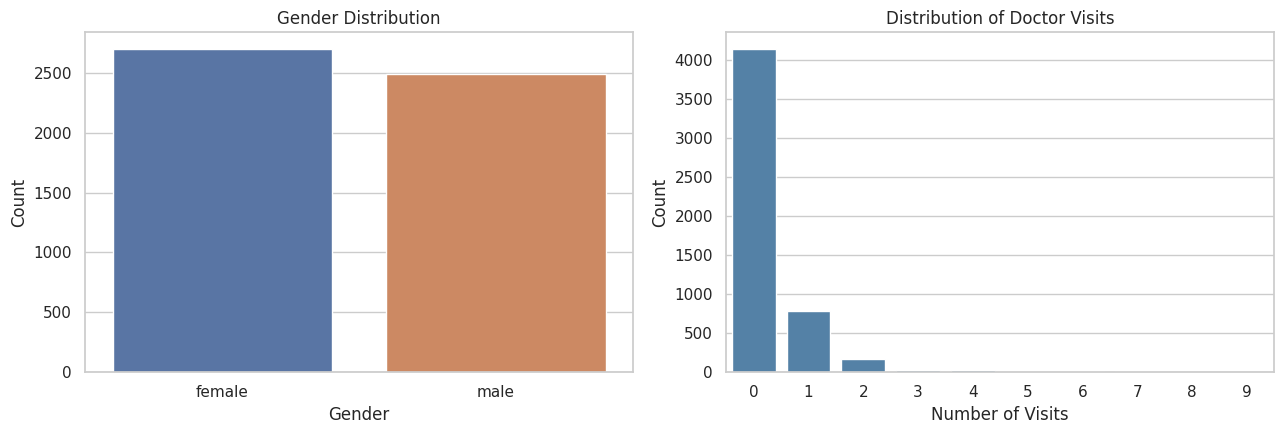

Mean visits: 0.302
Median visits: 0.000
Maximum visits: 9
Records with zero visits: 79.79%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=analysis_df, x="gender", hue="gender", legend=False, ax=axes[0])
axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

sns.countplot(data=analysis_df, x="visits", color="steelblue", ax=axes[1])
axes[1].set_title("Distribution of Doctor Visits")
axes[1].set_xlabel("Number of Visits")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Mean visits: {analysis_df.visits.mean():.3f}")
print(f"Median visits: {analysis_df.visits.median():.3f}")
print(f"Maximum visits: {analysis_df.visits.max()}")
print(f"Records with zero visits: {(analysis_df.visits == 0).mean()*100:.2f}%")


## 7. Gender and Age Analysis

,gender,count,mean,median
0,female,2702,0.362,0.0
1,male,2488,0.236,0.0


,age_group,count,mean,median
0,"(0.189, 0.22]",1965,0.206,0.0
1,"(0.22, 0.32]",824,0.252,0.0
2,"(0.32, 0.62]",1264,0.347,0.0
3,"(0.62, 0.72]",1137,0.454,0.0


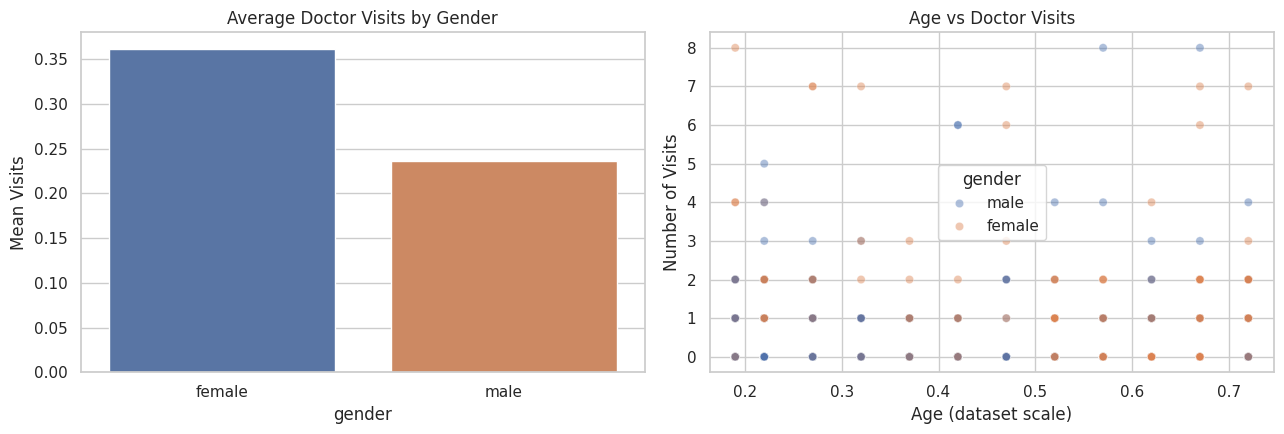

In [11]:
gender_summary = (
    analysis_df.groupby("gender")["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .round(3)
)
display(gender_summary)

analysis_df["age_group"] = pd.qcut(
    analysis_df["age"], q=4, duplicates="drop"
)
age_summary = (
    analysis_df.groupby("age_group", observed=True)["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .round(3)
)
display(age_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=gender_summary, x="gender", y="mean", hue="gender",
            legend=False, ax=axes[0])
axes[0].set_title("Average Doctor Visits by Gender")
axes[0].set_ylabel("Mean Visits")

sns.scatterplot(
    data=analysis_df.sample(min(1500, len(analysis_df)), random_state=42),
    x="age", y="visits", hue="gender", alpha=0.45, ax=axes[1]
)
axes[1].set_title("Age vs Doctor Visits")
axes[1].set_xlabel("Age (dataset scale)")
axes[1].set_ylabel("Number of Visits")

plt.tight_layout()
plt.show()


## 8. Health, Illness, and Activity Reduction

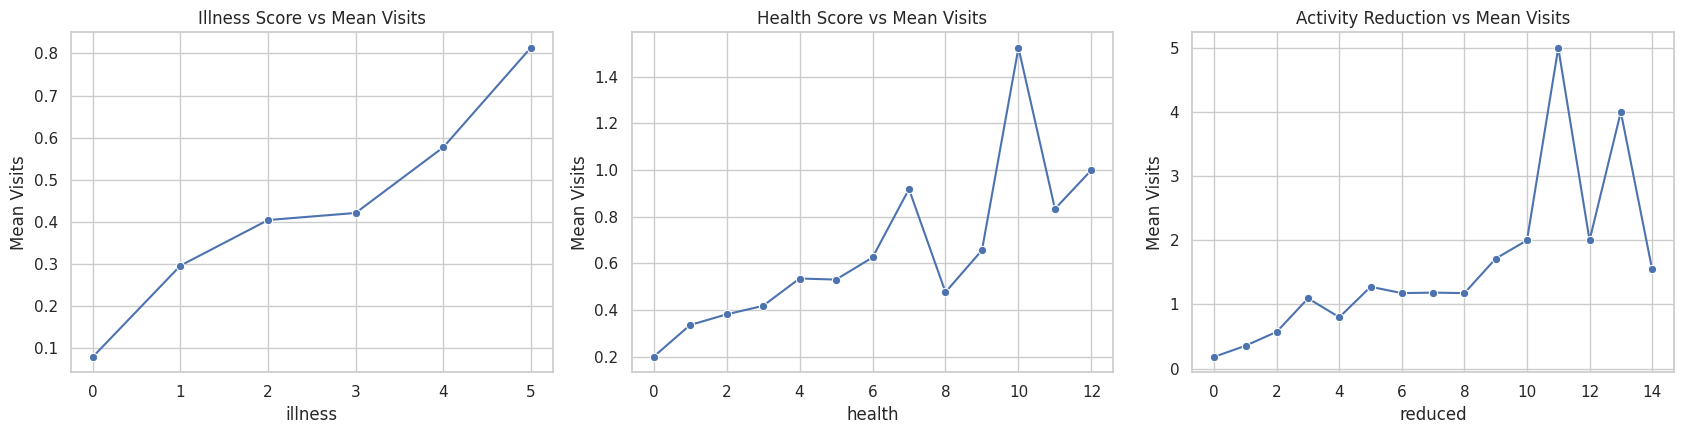

,illness,visits
0,0,0.079
1,1,0.295
2,2,0.404
3,3,0.421
4,4,0.577
5,5,0.814


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

illness_summary = analysis_df.groupby("illness")["visits"].mean().reset_index()
sns.lineplot(data=illness_summary, x="illness", y="visits", marker="o", ax=axes[0])
axes[0].set_title("Illness Score vs Mean Visits")

health_summary = analysis_df.groupby("health")["visits"].mean().reset_index()
sns.lineplot(data=health_summary, x="health", y="visits", marker="o", ax=axes[1])
axes[1].set_title("Health Score vs Mean Visits")

reduced_summary = analysis_df.groupby("reduced")["visits"].mean().reset_index()
sns.lineplot(data=reduced_summary, x="reduced", y="visits", marker="o", ax=axes[2])
axes[2].set_title("Activity Reduction vs Mean Visits")

for ax in axes:
    ax.set_ylabel("Mean Visits")

plt.tight_layout()
plt.show()

display(illness_summary.round(3))


## 9. Income and Healthcare-Access Analysis

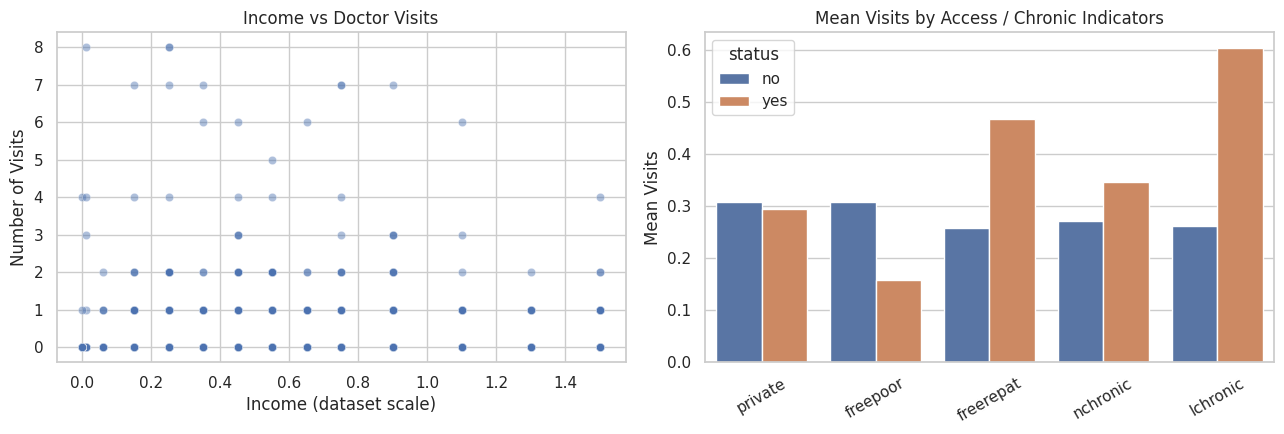


 private


,count,mean,median
private,,,
no,2892,0.307,0.0
yes,2298,0.295,0.0



 freepoor


,count,mean,median
freepoor,,,
no,4968,0.308,0.0
yes,222,0.158,0.0



 freerepat


,count,mean,median
freerepat,,,
no,4099,0.258,0.0
yes,1091,0.467,0.0



 nchronic


,count,mean,median
nchronic,,,
no,3098,0.272,0.0
yes,2092,0.346,0.0



 lchronic


,count,mean,median
lchronic,,,
no,4585,0.262,0.0
yes,605,0.603,0.0


In [13]:
access_cols = ["private", "freepoor", "freerepat", "nchronic", "lchronic"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.scatterplot(
    data=analysis_df.sample(min(1500, len(analysis_df)), random_state=42),
    x="income", y="visits", alpha=0.45, ax=axes[0]
)
axes[0].set_title("Income vs Doctor Visits")
axes[0].set_xlabel("Income (dataset scale)")
axes[0].set_ylabel("Number of Visits")

access_summary = []
for col in access_cols:
    tmp = analysis_df.groupby(col)["visits"].mean().reset_index()
    tmp["variable"] = col
    tmp["status"] = tmp[col].astype(str)
    access_summary.append(tmp[["variable", "status", "visits"]])

access_plot = pd.concat(access_summary, ignore_index=True)
sns.barplot(
    data=access_plot, x="variable", y="visits", hue="status", ax=axes[1]
)
axes[1].set_title("Mean Visits by Access / Chronic Indicators")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean Visits")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

for col in access_cols:
    print("\n", col)
    display(analysis_df.groupby(col)["visits"].agg(["count","mean","median"]).round(3))


## 10. Correlation Analysis

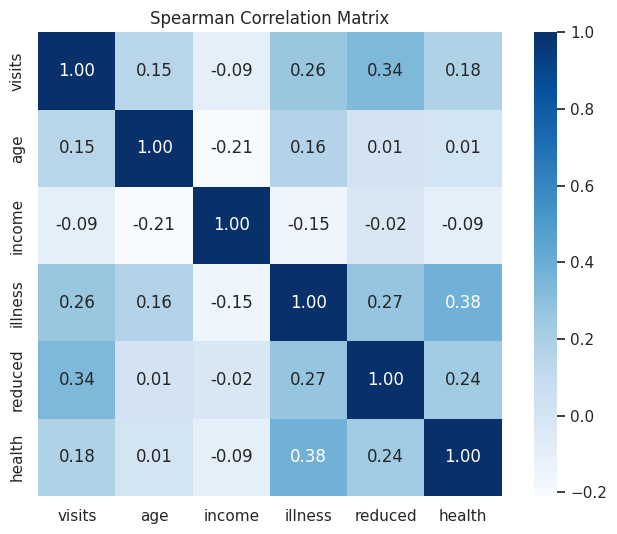

,Spearman correlation with visits
visits,1.000000
reduced,0.335574
illness,0.262679
health,0.177524
age,0.147560
income,-0.092795


In [14]:
numeric_cols = ["visits", "age", "income", "illness", "reduced", "health"]
spearman_corr = analysis_df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(7, 5.5))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="Blues", square=True)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

display(spearman_corr["visits"].sort_values(ascending=False).to_frame("Spearman correlation with visits"))


## 11. Statistical Significance Testing

Because doctor visits are a discrete, highly zero-heavy outcome, non-parametric tests are used for the main group comparisons. These tests indicate distributional differences/associations, not causation.

In [15]:
test_rows = []

# Spearman correlations
for col in ["age", "income", "illness", "reduced", "health"]:
    r, p = stats.spearmanr(analysis_df[col], analysis_df["visits"])
    test_rows.append({
        "analysis": "Spearman correlation",
        "variable": col,
        "statistic": r,
        "p_value": p
    })

# Mann-Whitney U for binary categorical variables
for col in ["gender", "private", "freepoor", "freerepat", "nchronic", "lchronic"]:
    groups = [g["visits"].values for _, g in analysis_df.groupby(col)]
    u, p = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    test_rows.append({
        "analysis": "Mann-Whitney U",
        "variable": col,
        "statistic": u,
        "p_value": p
    })

# Kruskal-Wallis for multi-level ordinal variables
for col in ["illness", "reduced", "health"]:
    groups = [g["visits"].values for _, g in analysis_df.groupby(col)]
    h, p = stats.kruskal(*groups)
    test_rows.append({
        "analysis": "Kruskal-Wallis",
        "variable": col,
        "statistic": h,
        "p_value": p
    })

tests_df = pd.DataFrame(test_rows)
tests_df["significant_at_0.05"] = tests_df["p_value"] < 0.05
display(tests_df.sort_values("p_value").round(6))


,analysis,variable,statistic,p_value,significant_at_0.05
12,Kruskal-Wallis,reduced,6.856812e+02,0.000000,True
3,Spearman correlation,reduced,3.355740e-01,0.000000,True
2,Spearman correlation,illness,2.626790e-01,0.000000,True
11,Kruskal-Wallis,illness,3.660393e+02,0.000000,True
13,Kruskal-Wallis,health,2.120978e+02,0.000000,True
4,Spearman correlation,health,1.775240e-01,0.000000,True
0,Spearman correlation,age,1.475600e-01,0.000000,True
8,Mann-Whitney U,freerepat,1.914797e+06,0.000000,True
10,Mann-Whitney U,lchronic,1.144248e+06,0.000000,True
5,Mann-Whitney U,gender,3.655194e+06,0.000000,True


## 12. Count Regression — Poisson GLM

In [16]:
# Encode binary variables numerically for the count model
model_df = analysis_df.drop(columns=["age_group"], errors="ignore").copy()
model_df["gender_female"] = (model_df["gender"] == "female").astype(int)

for col in ["private", "freepoor", "freerepat", "nchronic", "lchronic"]:
    model_df[col + "_yes"] = (model_df[col] == "yes").astype(int)

formula = (
    "visits ~ gender_female + age + income + illness + reduced + health + "
    "private_yes + freepoor_yes + freerepat_yes + nchronic_yes + lchronic_yes"
)

poisson_model = smf.glm(
    formula=formula,
    data=model_df,
    family=sm.families.Poisson()
).fit()

model_results = pd.DataFrame({
    "term": poisson_model.params.index,
    "coefficient": poisson_model.params.values,
    "IRR": np.exp(poisson_model.params.values),
    "p_value": poisson_model.pvalues.values
})

display(model_results.round(4))
print("AIC:", round(poisson_model.aic, 2))
print("Deviance / residual df:", round(poisson_model.deviance / poisson_model.df_resid, 3))


,term,coefficient,IRR,p_value
0,Intercept,-2.0978,0.1227,0.0000
1,gender_female,0.1565,1.1694,0.0053
2,age,0.2791,1.3220,0.0926
3,income,-0.1874,0.8291,0.0283
4,illness,0.1862,1.2046,0.0000
5,reduced,0.1267,1.1351,0.0000
6,health,0.0307,1.0312,0.0023
7,private_yes,0.1265,1.1348,0.0771
8,freepoor_yes,-0.4385,0.6450,0.0147
9,freerepat_yes,0.0836,1.0872,0.3636


AIC: 6735.7
Deviance / residual df: 0.846


## 13. Key Findings

In [17]:
print(f"• The dataset contains {len(analysis_df):,} records and {analysis_df.shape[1]:,} analysis variables after removing the index-like column.")
print(f"• Mean doctor visits = {analysis_df.visits.mean():.3f}; median = {analysis_df.visits.median():.1f}; {((analysis_df.visits==0).mean()*100):.2f}% of records have zero visits.")
print(f"• Female records have mean visits of {analysis_df.loc[analysis_df.gender=='female','visits'].mean():.3f}; male records have {analysis_df.loc[analysis_df.gender=='male','visits'].mean():.3f}.")
print(f"• Spearman correlation with visits: reduced={stats.spearmanr(analysis_df.reduced,analysis_df.visits).statistic:.3f}, illness={stats.spearmanr(analysis_df.illness,analysis_df.visits).statistic:.3f}, age={stats.spearmanr(analysis_df.age,analysis_df.visits).statistic:.3f}.")
print(f"• Long-term chronic condition: mean visits are {analysis_df.loc[analysis_df.lchronic=='yes','visits'].mean():.3f} for 'yes' and {analysis_df.loc[analysis_df.lchronic=='no','visits'].mean():.3f} for 'no'.")
print(f"• The private-insurance comparison is not statistically significant by Mann-Whitney U (p={tests_df.loc[(tests_df.analysis=='Mann-Whitney U') & (tests_df.variable=='private'),'p_value'].iloc[0]:.3f}).")


• The dataset contains 5,190 records and 13 analysis variables after removing the index-like column.
• Mean doctor visits = 0.302; median = 0.0; 79.79% of records have zero visits.
• Female records have mean visits of 0.362; male records have 0.236.
• Spearman correlation with visits: reduced=0.336, illness=0.263, age=0.148.
• Long-term chronic condition: mean visits are 0.603 for 'yes' and 0.262 for 'no'.
• The private-insurance comparison is not statistically significant by Mann-Whitney U (p=0.762).


## 14. Conclusion and Data-Driven Recommendations

### Conclusion
The analysis shows measurable associations between recorded doctor visits and several demographic, health, illness, activity-reduction, and chronic-condition indicators. Illness, activity reduction, health score, and age show positive rank associations with visits, while income shows a small negative rank association. Group comparisons also show statistically detectable differences for several categorical indicators.

### Recommendations
- Use illness and activity-reduction indicators as important variables when exploring healthcare-utilization patterns.
- Examine chronic-condition groups separately when planning utilization analyses.
- Treat insurance/access indicators individually rather than assuming all coverage variables have the same relationship with visits.
- Use non-parametric and count-based methods when analyzing highly zero-heavy visit counts.
- Avoid causal interpretations: the dataset supports association analysis, not medical or policy causality.


## 15. Limitations

- The analysis is based only on the supplied dataset.
- Doctor visits are highly concentrated at zero, so simple averages can hide distributional differences.
- Age and income are retained in the dataset's original scale; no external unit conversion is assumed.
- Statistical significance does not imply practical importance or causation.
- The Poisson model is used as an exploratory count model; model diagnostics should be considered before using it for operational prediction.


## 16. Final Project Summary

**Project:** Healthcare Analytics for Doctor Visits  
**Student:** Radheshyam Suthar  
**Dataset:** 5,190 records, 13 supplied columns  
**Analysis:** Data quality, EDA, demographic analysis, health/illness analysis, healthcare-access analysis, correlation, non-parametric statistical testing, and exploratory Poisson count regression.

**Reproducibility:** The dataset is loaded from the project's public GitHub repository, allowing the notebook to run in a fresh Google Colab runtime without a manual CSV upload.

